# Amplitude Scaling: Moran Blindspot And Edge-Only Half Edge

This notebook tests one proposed explanation for why Half Edge trends can look more like dissimilarity than Moran, even when we remove the within-tract term.

The counterfactual keeps each CBSA graph and tract population fixed, but scales every tract's POC share toward the CBSA-wide POC share:

`p_i(alpha) = p_bar + alpha * (p_i - p_bar)`

For `alpha=1`, the graph is observed. For smaller `alpha`, the spatial pattern is the same but the amplitude of tract share differences is compressed. Moran should be invariant for `alpha > 0`; dissimilarity and edge-only Half Edge should respond.

In [71]:
from pathlib import Path
# import sys  # Uncomment with the project-metrics block below.

from IPython.display import display
import gerrychain
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

relative_csv = Path("outputs/tracts_in_cbsa/white_black.csv")

for candidate_root in [Path.cwd(), *Path.cwd().parents]:
    if (candidate_root / relative_csv).exists() and (
        candidate_root / "pipeline" / "calculate_metrics.py"
    ).exists():
        project_root = candidate_root
        break
else:
    raise FileNotFoundError(f"Could not find {relative_csv} from {Path.cwd()}")

csv_path = project_root / relative_csv

# Project metric functions cast populations to int; keep this block commented for the floating counterfactual.
# if str(project_root) not in sys.path:
#     sys.path.insert(0, str(project_root))
# from pipeline import calculate_metrics as metrics

X_COL = "BLACK"
Y_COL = "WHITE"
TOT_COL = "TOTPOP"
ALPHAS = np.array([0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0])

csv_path

PosixPath('/Users/maria/Documents/capy-bara/outputs/tracts_in_cbsa/white_black.csv')

## Load Tract White-POC Outputs

The stored CSV metrics are used only for validation at `alpha=1`. The counterfactual metrics are calculated directly from floating counts so that scaling the shares does not introduce rounding noise. A commented import block in the setup cell can be restored if we want to compare against the integer-casting project metric functions later.

In [72]:
df = pd.read_csv(csv_path)

required_columns = [
    "filename",
    "x_col",
    "y_col",
    "tot_col",
    "dissimilarity",
    "moran",
    "half_edge_lam_0_angle_1",
    "half_edge_lam_1_angle_1",
    "total_population",
    "total_nodes",
    "total_edges",
]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

unexpected_x_cols = sorted(df.loc[df["x_col"].notna() & (df["x_col"] != X_COL), "x_col"].unique())
unexpected_y_cols = sorted(df.loc[df["y_col"].notna() & (df["y_col"] != Y_COL), "y_col"].unique())
unexpected_tot_cols = sorted(
    df.loc[df["tot_col"].notna() & (df["tot_col"] != TOT_COL), "tot_col"].unique()
)
if unexpected_x_cols or unexpected_y_cols or unexpected_tot_cols:
    raise ValueError(
        "Expected White-POC rows only, but found "
        f"x_col={unexpected_x_cols}, y_col={unexpected_y_cols}, tot_col={unexpected_tot_cols}"
    )

df["year"] = df["filename"].str.extract(r"study_areas/(\d{4})/").astype(int)
df["cbsa"] = df["filename"].str.extract(r"tracts_in_cbsa_(\d+)_")
df["area_key"] = df["year"].astype(str) + " CBSA " + df["cbsa"]

metric_rows = df.dropna(
    subset=["dissimilarity", "moran", "half_edge_lam_0_angle_1"]
).copy()
metric_rows["graph_path"] = metric_rows["filename"].apply(lambda filename: project_root / filename)
missing_graph_paths = metric_rows.loc[~metric_rows["graph_path"].apply(Path.exists), "graph_path"]
if len(missing_graph_paths):
    raise FileNotFoundError(f"Missing graph JSONs: {missing_graph_paths.head().tolist()}")

print(f"Loaded {len(metric_rows):,} White-POC tract CBSA rows.")
metric_rows[
    [
        "area_key",
        "total_population",
        "total_nodes",
        "total_edges",
        "dissimilarity",
        "moran",
        "half_edge_lam_0_angle_1",
        "half_edge_lam_1_angle_1",
        "filename",
    ]
].head()

Loaded 1,939 White-POC tract CBSA rows.


,area_key,total_population,total_nodes,total_edges,dissimilarity,moran,half_edge_lam_0_angle_1,half_edge_lam_1_angle_1,filename
0,2020 CBSA 42700,101235,33,78,0.420530,0.210687,0.514135,0.524001,study_areas/2020/tracts_in_cbsa_42700_2020_mar...
1,2020 CBSA 23900,103852,27,58,0.311980,0.463480,0.502743,0.503427,study_areas/2020/tracts_in_cbsa_23900_2020_mar...
2,2020 CBSA 22520,150791,41,101,0.418184,0.213163,0.521502,0.527752,study_areas/2020/tracts_in_cbsa_22520_2020_mar...
3,2020 CBSA 14540,179639,44,107,0.484534,0.308329,0.529320,0.533887,study_areas/2020/tracts_in_cbsa_14540_2020_mar...
4,2020 CBSA 43300,135543,30,72,0.439671,0.420894,0.512479,0.516378,study_areas/2020/tracts_in_cbsa_43300_2020_mar...


## Scale Composition Amplitude

For each graph, `p_bar` is the population-weighted CBSA-wide POC share. Scaling around this value keeps the total POC and White counts fixed while compressing differences across tracts.

`p_i(alpha) = p_bar + alpha * (p_i - p_bar)`

At `alpha=0`, every tract has the same POC share, so dissimilarity is zero, edge-only Half Edge is `0.5`, and Moran is undefined because the share variance is zero.

In [73]:
counterfactual_records = []

for row_number, area in enumerate(metric_rows.itertuples(index=False), start=1):
    graph = gerrychain.Graph.from_json(area.graph_path)
    node_order = list(graph.nodes())
    node_index = {node: index for index, node in enumerate(node_order)}
    edge_indices = [(node_index[u], node_index[v]) for u, v in graph.edges()]

    observed_x = np.array([float(graph.nodes[node][X_COL]) for node in node_order], dtype=float)
    observed_y = np.array([float(graph.nodes[node][Y_COL]) for node in node_order], dtype=float)
    tract_totals = observed_x + observed_y
    valid_total = tract_totals > 0
    if not valid_total.all():
        raise ValueError(f"Found zero-population nodes in {area.filename}")

    observed_share = observed_x / tract_totals
    metro_share = observed_x.sum() / tract_totals.sum()

    for alpha in ALPHAS:
        scaled_share = metro_share + alpha * (observed_share - metro_share)
        if scaled_share.min() < -1e-12 or scaled_share.max() > 1 + 1e-12:
            raise ValueError(f"Scaled shares outside [0, 1] for {area.area_key}, alpha={alpha}")
        scaled_share = np.clip(scaled_share, 0, 1)

        x_counts = scaled_share * tract_totals
        y_counts = (1 - scaled_share) * tract_totals
        total_x = x_counts.sum()
        total_population = tract_totals.sum()

        dissimilarity_numerator = np.abs(
            x_counts * total_population - tract_totals * total_x
        ).sum()
        dissimilarity_denominator = 2 * total_x * (total_population - total_x)
        dissimilarity = dissimilarity_numerator / dissimilarity_denominator

        moran_mean = scaled_share.mean()
        moran_bottom = ((scaled_share - moran_mean) ** 2).sum()
        moran_top = 0.0
        for node_index_a, node_index_b in edge_indices:
            moran_top += (scaled_share[node_index_a] - moran_mean) * (
                scaled_share[node_index_b] - moran_mean
            )
        moran = (
            (len(node_order) / len(edge_indices)) * (moran_top / moran_bottom)
            if moran_bottom > 1e-24
            else np.nan
        )

        between_xx = 0.0
        between_xy = 0.0
        between_yy = 0.0
        for node_index_a, node_index_b in edge_indices:
            x_a = x_counts[node_index_a]
            y_a = y_counts[node_index_a]
            x_b = x_counts[node_index_b]
            y_b = y_counts[node_index_b]

            between_xx += x_a * x_b + x_b * x_a
            between_xy += x_a * y_b + x_b * y_a
            between_yy += y_a * y_b + y_b * y_a

        half_edge_lam_0_angle_1 = 0.5 * (
            between_xx / (between_xx + between_xy)
            + between_yy / (between_yy + between_xy)
        )

        counterfactual_records.append(
            {
                "area_key": area.area_key,
                "year": area.year,
                "cbsa": area.cbsa,
                "filename": area.filename,
                "alpha": alpha,
                "metro_share": metro_share,
                "dissimilarity": dissimilarity,
                "moran": moran,
                "half_edge_lam_0_angle_1": half_edge_lam_0_angle_1,
                "between_xx": between_xx,
                "between_xy": between_xy,
                "between_yy": between_yy,
            }
        )

    if row_number % 100 == 0:
        print(f"Processed {row_number:,} graph JSONs...")

counterfactual = pd.DataFrame(counterfactual_records)
print(f"Built {len(counterfactual):,} counterfactual metric rows.")
counterfactual.head()

Processed 100 graph JSONs...
Processed 200 graph JSONs...
Processed 300 graph JSONs...
Processed 400 graph JSONs...
Processed 500 graph JSONs...
Processed 600 graph JSONs...
Processed 700 graph JSONs...
Processed 800 graph JSONs...
Processed 900 graph JSONs...
Processed 1,000 graph JSONs...
Processed 1,100 graph JSONs...
Processed 1,200 graph JSONs...
Processed 1,300 graph JSONs...
Processed 1,400 graph JSONs...
Processed 1,500 graph JSONs...
Processed 1,600 graph JSONs...
Processed 1,700 graph JSONs...
Processed 1,800 graph JSONs...
Processed 1,900 graph JSONs...
Built 13,573 counterfactual metric rows.


,area_key,year,cbsa,filename,alpha,metro_share,dissimilarity,moran,half_edge_lam_0_angle_1,between_xx,between_xy,between_yy
0,2020 CBSA 42700,2020,42700,study_areas/2020/tracts_in_cbsa_42700_2020_mar...,0.00,0.126462,8.698739e-17,NaN,0.500000,1.440286e+07,9.948814e+07,6.872171e+08
1,2020 CBSA 42700,2020,42700,study_areas/2020/tracts_in_cbsa_42700_2020_mar...,0.05,0.126462,2.102649e-02,0.210687,0.500033,1.431423e+07,9.919953e+07,6.878830e+08
2,2020 CBSA 42700,2020,42700,study_areas/2020/tracts_in_cbsa_42700_2020_mar...,0.10,0.126462,4.205298e-02,0.210687,0.500134,1.423918e+07,9.889735e+07,6.885624e+08
3,2020 CBSA 42700,2020,42700,study_areas/2020/tracts_in_cbsa_42700_2020_mar...,0.25,0.126462,1.051324e-01,0.210687,0.500845,1.409547e+07,9.790936e+07,6.906821e+08
4,2020 CBSA 42700,2020,42700,study_areas/2020/tracts_in_cbsa_42700_2020_mar...,0.50,0.126462,2.102649e-01,0.210687,0.503429,1.412742e+07,9.599126e+07,6.944864e+08


## Validate `alpha=1`

At `alpha=1`, the counterfactual should reproduce the metrics already stored in `white_poc.csv`. This check confirms the floating formulas match the project implementation before we interpret the scaling experiment.

In [74]:
observed_counterfactual = counterfactual[counterfactual["alpha"].eq(1.0)].merge(
    metric_rows[
        [
            "area_key",
            "dissimilarity",
            "moran",
            "half_edge_lam_0_angle_1",
        ]
    ],
    on="area_key",
    suffixes=("_counterfactual", "_csv"),
    validate="one_to_one",
)

validation_rows = []
for metric in ["dissimilarity", "moran", "half_edge_lam_0_angle_1"]:
    error = (
        observed_counterfactual[f"{metric}_counterfactual"]
        - observed_counterfactual[f"{metric}_csv"]
    ).abs()
    validation_rows.append(
        {
            "metric": metric,
            "max_abs_error": error.max(),
            "median_abs_error": error.median(),
        }
    )

validation = pd.DataFrame(validation_rows)
display(validation)

if validation["max_abs_error"].max() > 1e-10:
    raise AssertionError("Counterfactual alpha=1 metrics do not match the CSV metrics")

,metric,max_abs_error,median_abs_error
0,dissimilarity,2.220446e-16,0.000000e+00
1,moran,4.107825e-15,6.938894e-17
2,half_edge_lam_0_angle_1,1.110223e-16,0.000000e+00


## Yearly Means By Alpha

Each panel below fixes the amplitude-scaling value and plots the yearly mean of Moran, edge-only Half Edge, and dissimilarity across CBSAs.

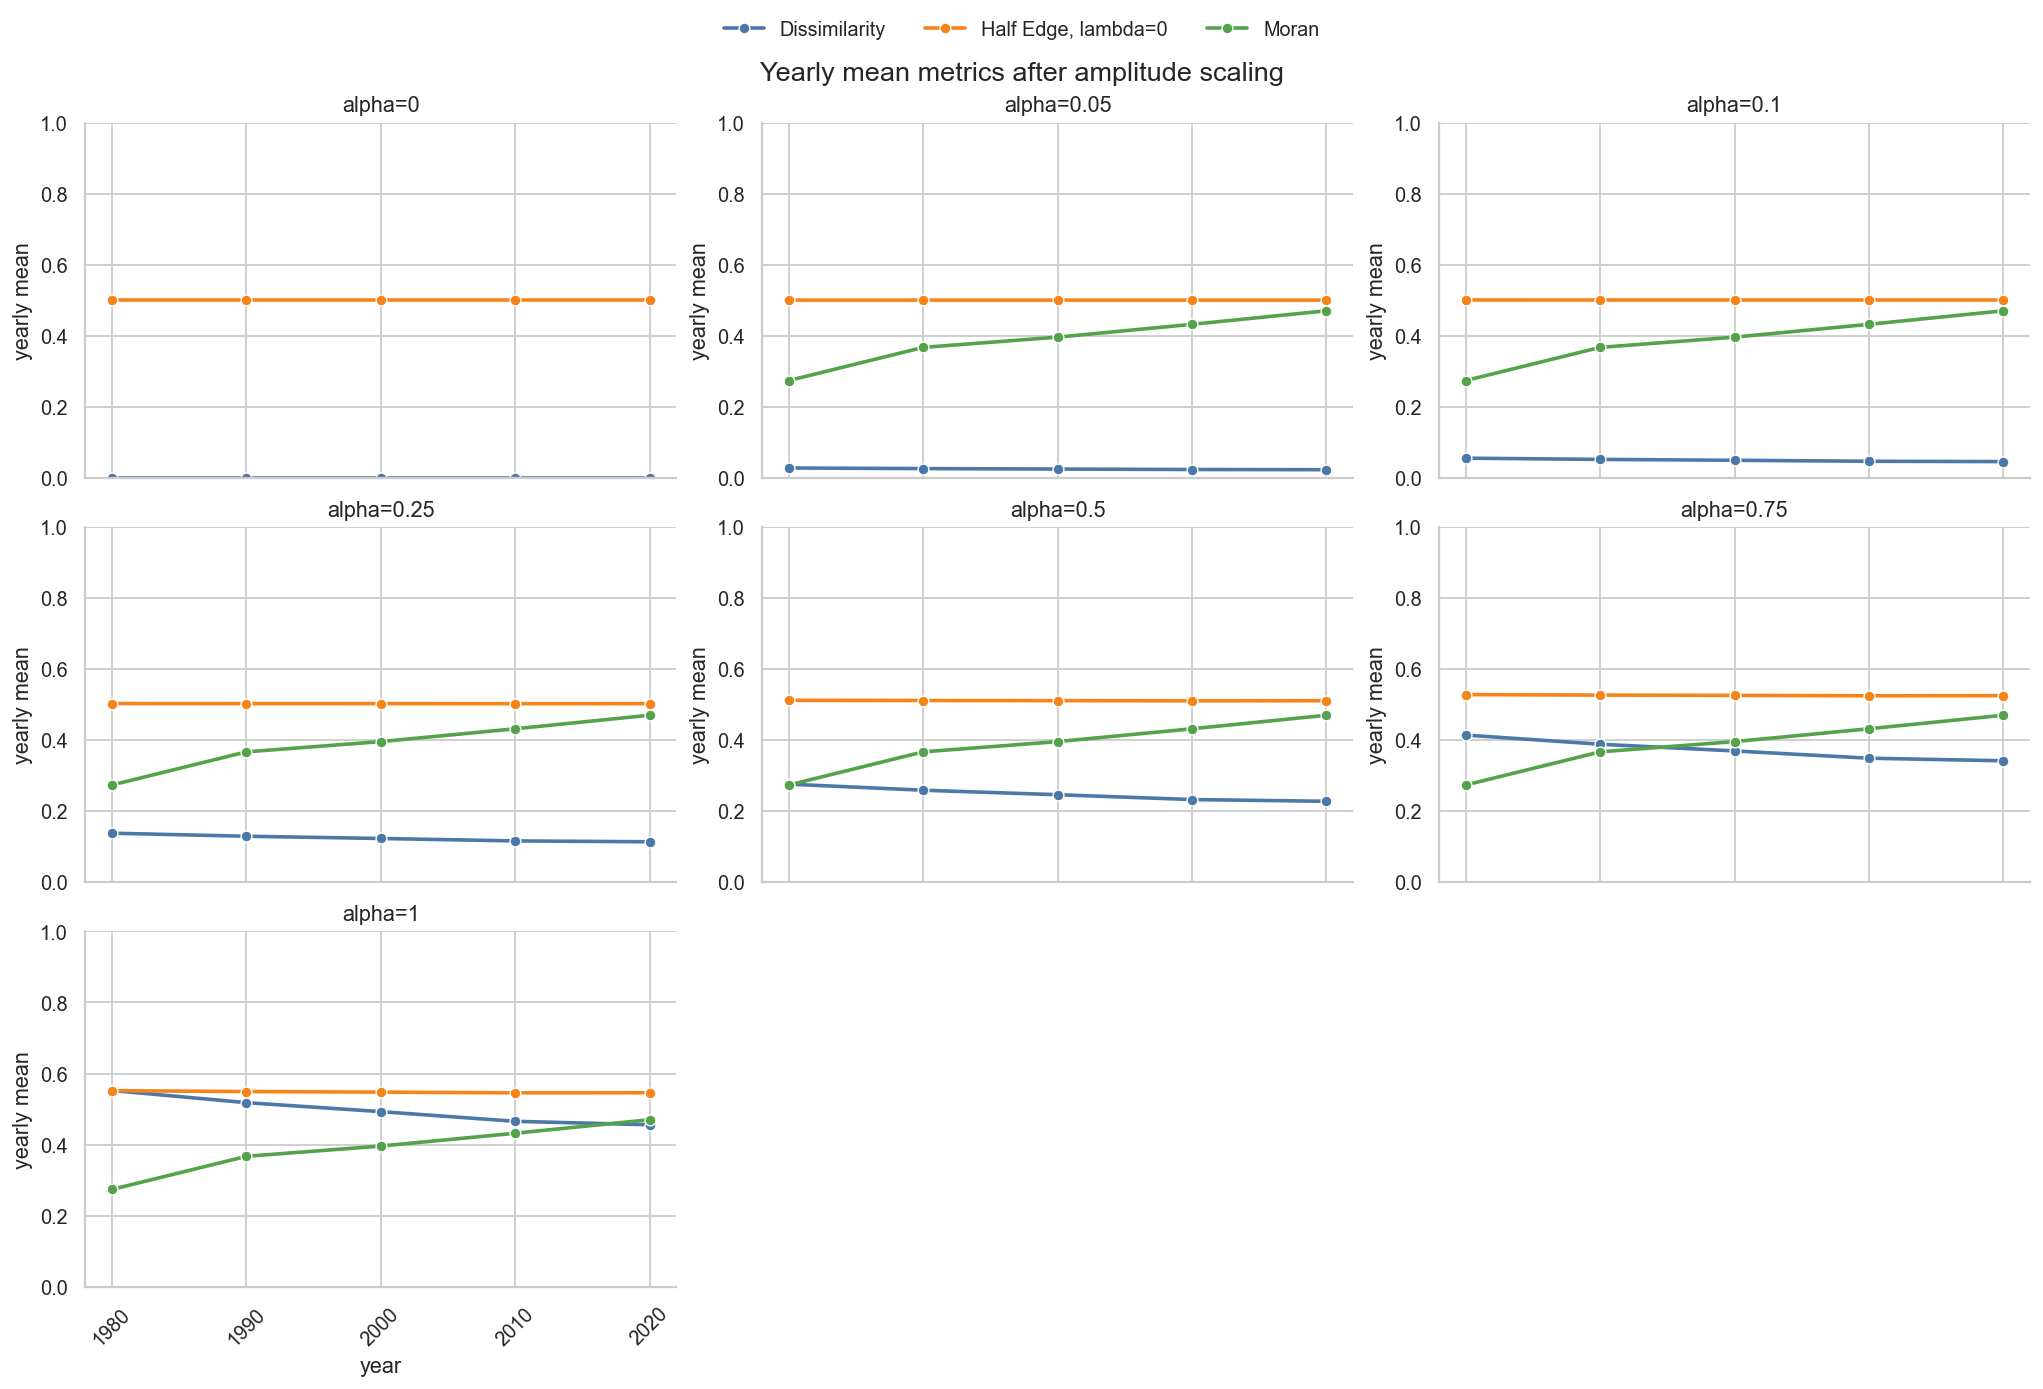

,alpha,year,dissimilarity,moran,half_edge_lam_0_angle_1
0,0.00,1980,4.241652e-17,NaN,0.500000
1,0.00,1990,4.186567e-17,NaN,0.500000
2,0.00,2000,4.498714e-17,NaN,0.500000
3,0.00,2010,4.246286e-17,NaN,0.500000
4,0.00,2020,4.786393e-17,NaN,0.500000
5,0.05,1980,2.761685e-02,0.273804,0.500116
6,0.05,1990,2.590328e-02,0.367054,0.500110
7,0.05,2000,2.463967e-02,0.395895,0.500106
8,0.05,2010,2.327698e-02,0.431969,0.500103
9,0.05,2020,2.279239e-02,0.470060,0.500106


In [75]:
yearly_metric_means = (
    counterfactual.groupby(["alpha", "year"], as_index=False)[
        ["dissimilarity", "moran", "half_edge_lam_0_angle_1"]
    ]
    .mean()
    .sort_values(["alpha", "year"])
)

metric_labels = {
    "dissimilarity": "Dissimilarity",
    "half_edge_lam_0_angle_1": "Half Edge, lambda=0",
    "moran": "Moran",
}
metric_palette = {
    "Dissimilarity": "#4C78A8",
    "Half Edge, lambda=0": "#F58518",
    "Moran": "#54A24B",
}

yearly_metric_means_long = yearly_metric_means.melt(
    id_vars=["alpha", "year"],
    value_vars=list(metric_labels),
    var_name="metric",
    value_name="yearly_mean",
)
yearly_metric_means_long["metric_label"] = yearly_metric_means_long["metric"].map(
    metric_labels
)

alpha_values = sorted(yearly_metric_means_long["alpha"].unique())
year_values = sorted(yearly_metric_means_long["year"].unique())
ncols = 3
nrows = int(np.ceil(len(alpha_values) / ncols))
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.2 * ncols, 3.4 * nrows),
    constrained_layout=True,
    squeeze=False,
    sharex=True,
)

for ax, alpha in zip(axes.flat, alpha_values):
    alpha_data = yearly_metric_means_long[yearly_metric_means_long["alpha"].eq(alpha)]
    sns.lineplot(
        data=alpha_data,
        x="year",
        y="yearly_mean",
        hue="metric_label",
        hue_order=list(metric_labels.values()),
        palette=metric_palette,
        marker="o",
        linewidth=2,
        ax=ax,
    )
    ax.set_title(f"alpha={alpha:g}")
    ax.set_xlabel("year")
    ax.set_ylabel("yearly mean")
    ax.set_ylim(0, 1)
    ax.set_xticks(year_values)
    ax.tick_params(axis="x", rotation=45)

for ax in axes.flat[len(alpha_values) :]:
    ax.set_axis_off()

handles, labels = axes.flat[0].get_legend_handles_labels()
for ax in axes.flat:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncols=len(metric_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),
)
fig.suptitle("Yearly mean metrics after amplitude scaling", fontsize=15)
plt.show()

yearly_metric_means.head(10)

## Half Edge Distributions By Year

The yearly means can hide movement in the distribution. These violins show the full CBSA distribution of edge-only Half Edge values for each year, separately for each `alpha`.

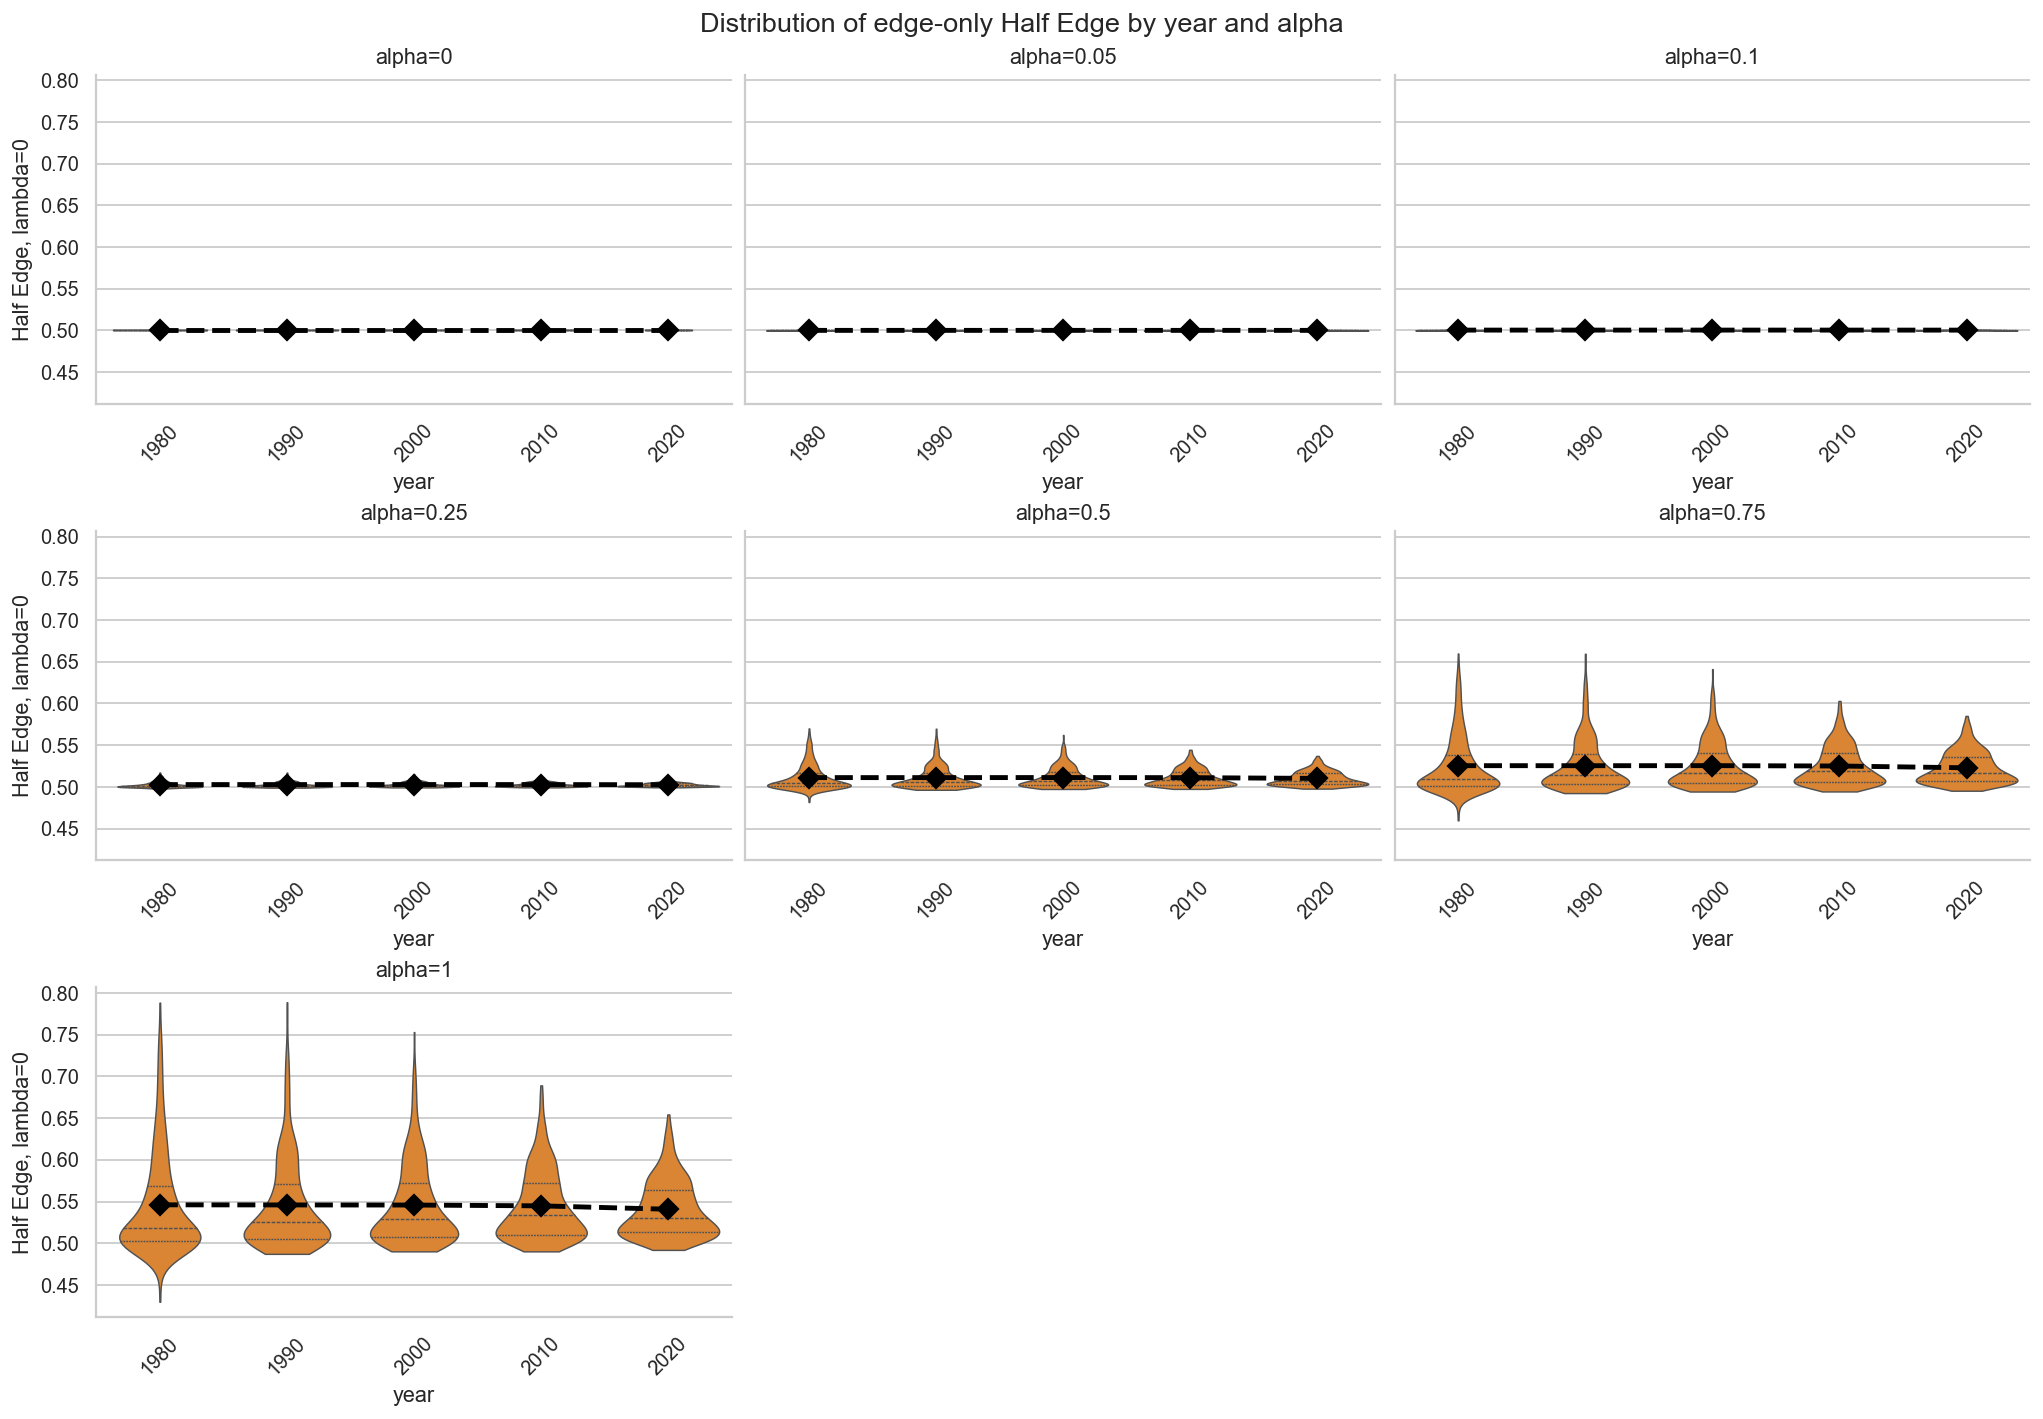

In [36]:
half_edge_distribution = counterfactual.dropna(subset=["half_edge_lam_0_angle_1"]).copy()
half_edge_distribution["year_label"] = half_edge_distribution["year"].astype(str)

alpha_values = sorted(half_edge_distribution["alpha"].unique())
year_labels = [str(year) for year in sorted(half_edge_distribution["year"].unique())]
ncols = 3
nrows = int(np.ceil(len(alpha_values) / ncols))
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.2 * ncols, 3.6 * nrows),
    constrained_layout=True,
    squeeze=False,
    sharey=True,
)

for ax, alpha in zip(axes.flat, alpha_values):
    alpha_data = half_edge_distribution[half_edge_distribution["alpha"].eq(alpha)]
    sns.violinplot(
        data=alpha_data,
        x="year_label",
        y="half_edge_lam_0_angle_1",
        order=year_labels,
        inner="quartile",
        cut=0,
        linewidth=0.8,
        color="#F58518",
        ax=ax,
    )
    sns.pointplot(
        data=alpha_data,
        x="year_label",
        y="half_edge_lam_0_angle_1",
        order=year_labels,
        estimator="mean",
        errorbar=None,
        color="black",
        markers="D",
        linestyles="--",
        ax=ax,
    )
    ax.set_title(f"alpha={alpha:g}")
    ax.set_xlabel("year")
    ax.set_ylabel("Half Edge, lambda=0")
    ax.tick_params(axis="x", rotation=45)

for ax in axes.flat[len(alpha_values) :]:
    ax.set_axis_off()

fig.suptitle("Distribution of edge-only Half Edge by year and alpha", fontsize=15)
plt.show()


## Tract POC Share Difference Amplitude By Year

Define tract-level share difference as `p_i - p_bar`, where `p_i` is tract POC share and `p_bar` is the population-weighted CBSA POC share. The amplitude is the absolute difference, `|p_i - p_bar|`.

For a CBSA-year scalar, use the population-weighted mean absolute difference:

`amplitude = sum_i n_i * |p_i - p_bar| / sum_i n_i`

This is in POC-share points, so `0.10` means the average resident lives in a tract whose POC share is 10 percentage points away from the metro-wide POC share. The code below derives it from dissimilarity because, for two groups, `amplitude = D * 2 * p_bar * (1 - p_bar)`.


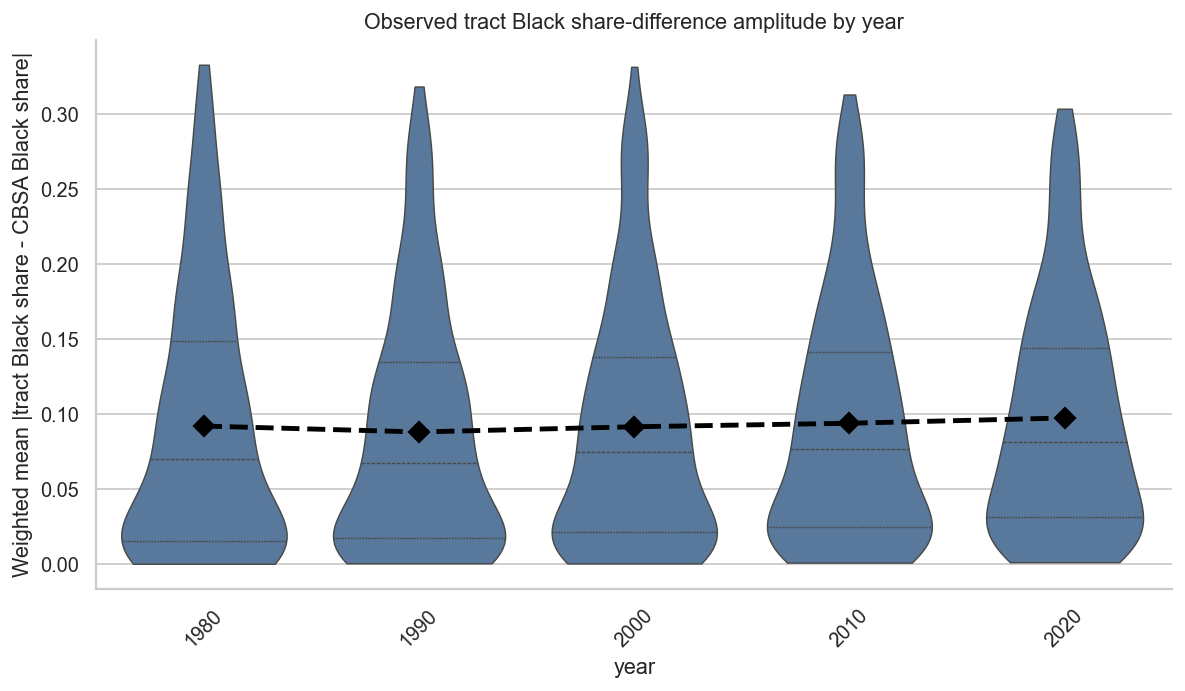

KeyError: 'Column not found: black_share_amplitude'

In [ ]:
counterfactual["poc_share_amplitude"] = (
    counterfactual["dissimilarity"]
    * 2
    * counterfactual["metro_share"]
    * (1 - counterfactual["metro_share"])
)

observed_amplitude = counterfactual[counterfactual["alpha"].eq(1.0)].copy()
observed_amplitude["year_label"] = observed_amplitude["year"].astype(str)

year_labels = [str(year) for year in sorted(observed_amplitude["year"].unique())]

fig, ax = plt.subplots(figsize=(9, 5.2), constrained_layout=True)
sns.violinplot(
    data=observed_amplitude,
    x="year_label",
    y="poc_share_amplitude",
    order=year_labels,
    inner="quartile",
    cut=0,
    linewidth=0.8,
    color="#4C78A8",
    ax=ax,
)
sns.pointplot(
    data=observed_amplitude,
    x="year_label",
    y="poc_share_amplitude",
    order=year_labels,
    estimator="mean",
    errorbar=None,
    color="black",
    markers="D",
    linestyles="--",
    ax=ax,
)
ax.set_xlabel("year")
ax.set_ylabel("Weighted mean |tract POC share - CBSA POC share|")
ax.set_title("Observed tract POC share-difference amplitude by year")
ax.tick_params(axis="x", rotation=45)
plt.show()

amplitude_summary = (
    observed_amplitude.groupby("year")["poc_share_amplitude"]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .reset_index()
)
amplitude_summary


## Generated-Figure Style Lines At Alpha 0.5

This reproduces the `pipeline/generate_figures.py` line-plot style for the top 10 CBSAs by 2020 population, but uses the amplitude-scaled counterfactual metrics at `alpha=0.5`. Because this notebook only calculates three counterfactual metrics, the plots are for edge-only Half Edge, Moran, and dissimilarity.

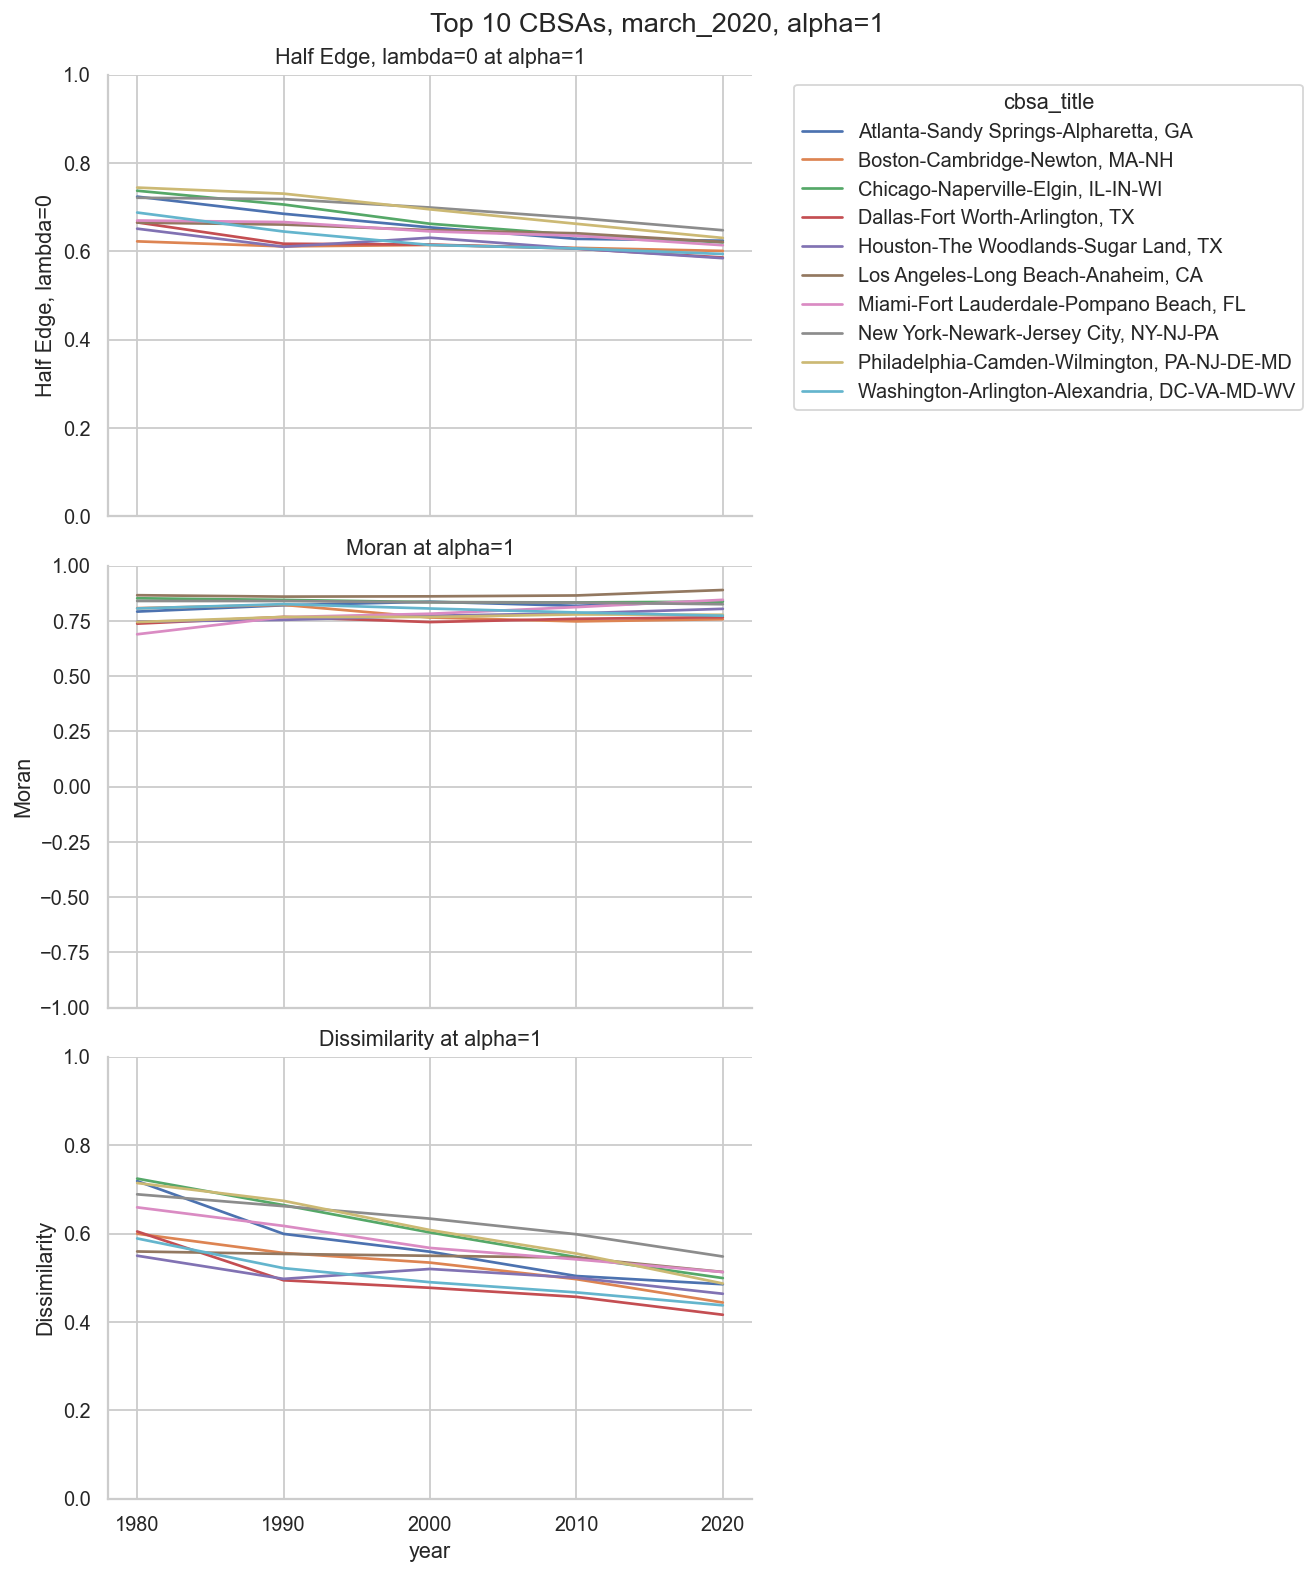

,cbsa_title,year,definition_month_year,total_population_2020,half_edge_lam_0_angle_1,moran,dissimilarity
1725,"Atlanta-Sandy Springs-Alpharetta, GA",1980,march_2020,6089815,0.723765,0.792252,0.718657
1257,"Atlanta-Sandy Springs-Alpharetta, GA",1990,march_2020,6089815,0.684977,0.820867,0.599195
848,"Atlanta-Sandy Springs-Alpharetta, GA",2000,march_2020,6089815,0.654197,0.836963,0.558798
537,"Atlanta-Sandy Springs-Alpharetta, GA",2010,march_2020,6089815,0.628209,0.818441,0.503773
268,"Atlanta-Sandy Springs-Alpharetta, GA",2020,march_2020,6089815,0.624092,0.840089,0.485206
1673,"Boston-Cambridge-Newton, MA-NH",1980,march_2020,4941632,0.622559,0.807727,0.599543
1216,"Boston-Cambridge-Newton, MA-NH",1990,march_2020,4941632,0.611199,0.822597,0.555953
811,"Boston-Cambridge-Newton, MA-NH",2000,march_2020,4941632,0.614394,0.765527,0.534161
490,"Boston-Cambridge-Newton, MA-NH",2010,march_2020,4941632,0.607861,0.747879,0.496681
239,"Boston-Cambridge-Newton, MA-NH",2020,march_2020,4941632,0.600904,0.757714,0.443797


In [63]:
import json

alpha_focus = 1
n_top_metros = 10
metrics_for_generated_style_plot = [
    "half_edge_lam_0_angle_1",
    "moran",
    "dissimilarity",
]
generated_style_metric_titles = {
    "half_edge_lam_0_angle_1": "Half Edge, lambda=0",
    "moran": "Moran",
    "dissimilarity": "Dissimilarity",
}
generated_style_y_limits = {
    "half_edge_lam_0_angle_1": (0, 1),
    "moran": (-1, 1),
    "dissimilarity": (0, 1),
}

plot_metadata = metric_rows[["filename", "year", "cbsa"]].copy()
definition_parts = plot_metadata["filename"].str.extract(
    r"_(?P<definition_month>[a-z]+)_(?P<definition_year>\d{4})_vintage"
)
plot_metadata["definition_month_year"] = (
    definition_parts["definition_month"] + "_" + definition_parts["definition_year"]
)

definition_records = []
for definition_key in plot_metadata[["cbsa", "definition_month_year"]].drop_duplicates().itertuples(
    index=False
):
    definition_path = (
        project_root
        / "study_areas"
        / "definitions"
        / f"cbsa_{definition_key.cbsa}_{definition_key.definition_month_year}.json"
    )
    if not definition_path.exists():
        fallback_paths = sorted(
            (project_root / "cbsas" / "defs").glob(
                f"*_{definition_key.cbsa}_{definition_key.definition_month_year}.json"
            )
        )
        if not fallback_paths:
            raise FileNotFoundError(definition_path)
        definition_path = fallback_paths[0]

    with open(definition_path) as definition_file:
        definition = json.load(definition_file)
    definition_records.append(
        {
            "cbsa": definition_key.cbsa,
            "definition_month_year": definition_key.definition_month_year,
            "cbsa_title": definition["cbsa_title"],
            "total_population_2020": definition["total_population"],
        }
    )

plot_metadata = plot_metadata.merge(
    pd.DataFrame(definition_records),
    on=["cbsa", "definition_month_year"],
    how="left",
    validate="many_to_one",
)
if plot_metadata[["cbsa_title", "total_population_2020"]].isna().any().any():
    raise ValueError("Missing CBSA metadata for some plot rows")

alpha_plot_data = counterfactual[counterfactual["alpha"].eq(alpha_focus)].merge(
    plot_metadata,
    on=["filename", "year"],
    how="left",
    validate="one_to_one",
)

for month_year in sorted(alpha_plot_data["definition_month_year"].dropna().unique()):
    month_year_df = alpha_plot_data[
        alpha_plot_data["definition_month_year"].eq(month_year)
    ].sort_values("total_population_2020", ascending=False)

    top_n_metros = set(month_year_df["cbsa_title"].drop_duplicates()[:n_top_metros])
    top_n_df = month_year_df[
        month_year_df["cbsa_title"].apply(lambda value: value in top_n_metros)
    ].sort_values(["cbsa_title", "year"])

    fig, axes = plt.subplots(
        nrows=len(metrics_for_generated_style_plot),
        ncols=1,
        figsize=(10, 4 * len(metrics_for_generated_style_plot)),
        constrained_layout=True,
        sharex=True,
    )
    if len(metrics_for_generated_style_plot) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics_for_generated_style_plot):
        sns.lineplot(
            data=top_n_df,
            y=metric,
            x="year",
            hue="cbsa_title",
            legend=(metric == metrics_for_generated_style_plot[0]),
            ax=ax,
        )
        ax.set_xticks(sorted(top_n_df["year"].unique()))
        ax.set_title(f"{generated_style_metric_titles[metric]} at alpha={alpha_focus:g}")
        ax.set_xlabel("year")
        ax.set_ylabel(generated_style_metric_titles[metric])
        ax.set_ylim(*generated_style_y_limits[metric])

        if metric == metrics_for_generated_style_plot[0]:
            ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="cbsa_title")
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

    fig.suptitle(
        f"Top {n_top_metros} CBSAs, {month_year}, alpha={alpha_focus:g}",
        fontsize=15,
    )
    plt.show()

top_n_df[
    [
        "cbsa_title",
        "year",
        "definition_month_year",
        "total_population_2020",
        *metrics_for_generated_style_plot,
    ]
].head(20)

## Normalize The Scaling Response

Dissimilarity is naturally zero when `alpha=0`, so its response is shown as `D(alpha) / D(1)`.

Edge-only Half Edge equals `0.5` when every tract has the same group share, so its response is shown as `(HE0(alpha) - 0.5) / (HE0(1) - 0.5)`.

Moran is shown as a difference from `Moran(1)` because it should be invariant for all positive `alpha`.

In [67]:
observed_by_area = counterfactual[counterfactual["alpha"].eq(1.0)].set_index("area_key")

counterfactual["observed_dissimilarity"] = counterfactual["area_key"].map(
    observed_by_area["dissimilarity"]
)
counterfactual["observed_moran"] = counterfactual["area_key"].map(observed_by_area["moran"])
counterfactual["observed_half_edge_lam_0_angle_1"] = counterfactual["area_key"].map(
    observed_by_area["half_edge_lam_0_angle_1"]
)

counterfactual["dissimilarity_ratio"] = (
    counterfactual["dissimilarity"] / counterfactual["observed_dissimilarity"]
)
counterfactual["he0_excess"] = counterfactual["half_edge_lam_0_angle_1"] - 0.5
counterfactual["observed_he0_excess"] = (
    counterfactual["observed_half_edge_lam_0_angle_1"] - 0.5
)
counterfactual["he0_excess_ratio"] = np.where(
    counterfactual["observed_he0_excess"].abs() > 1e-12,
    counterfactual["he0_excess"] / counterfactual["observed_he0_excess"],
    np.nan,
)
counterfactual["moran_delta"] = counterfactual["moran"] - counterfactual["observed_moran"]
counterfactual["moran_abs_delta"] = counterfactual["moran_delta"].abs()

alpha_summary = (
    counterfactual.groupby("alpha")
    .agg(
        dissimilarity_ratio_median=("dissimilarity_ratio", "median"),
        dissimilarity_ratio_p10=("dissimilarity_ratio", lambda values: values.quantile(0.10)),
        dissimilarity_ratio_p90=("dissimilarity_ratio", lambda values: values.quantile(0.90)),
        he0_excess_ratio_median=("he0_excess_ratio", "median"),
        he0_excess_ratio_p10=("he0_excess_ratio", lambda values: values.quantile(0.10)),
        he0_excess_ratio_p90=("he0_excess_ratio", lambda values: values.quantile(0.90)),
        moran_abs_delta_median=("moran_abs_delta", "median"),
        moran_abs_delta_max=("moran_abs_delta", "max"),
    )
    .reset_index()
)

alpha_summary

,alpha,dissimilarity_ratio_median,dissimilarity_ratio_p10,dissimilarity_ratio_p90,he0_excess_ratio_median,he0_excess_ratio_p10,he0_excess_ratio_p90,moran_abs_delta_median,moran_abs_delta_max
0,0.00,9.408014e-17,1.984672e-17,3.736722e-16,0.000000,-4.396151e-15,2.846123e-15,NaN,NaN
1,0.05,5.000000e-02,5.000000e-02,5.000000e-02,0.002465,2.260276e-03,2.577486e-03,3.330669e-16,2.022618e-13
2,0.10,1.000000e-01,1.000000e-01,1.000000e-01,0.009865,9.085264e-03,1.029200e-02,2.220446e-16,1.093570e-13
3,0.25,2.500000e-01,2.500000e-01,2.500000e-01,0.061793,5.763287e-02,6.401199e-02,1.110223e-16,3.483325e-14
4,0.50,5.000000e-01,5.000000e-01,5.000000e-01,0.248098,2.366548e-01,2.539932e-01,8.326673e-17,2.550737e-14
5,0.75,7.500000e-01,7.500000e-01,7.500000e-01,0.560318,5.469459e-01,5.669427e-01,1.110223e-16,2.281161e-14
6,1.00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00


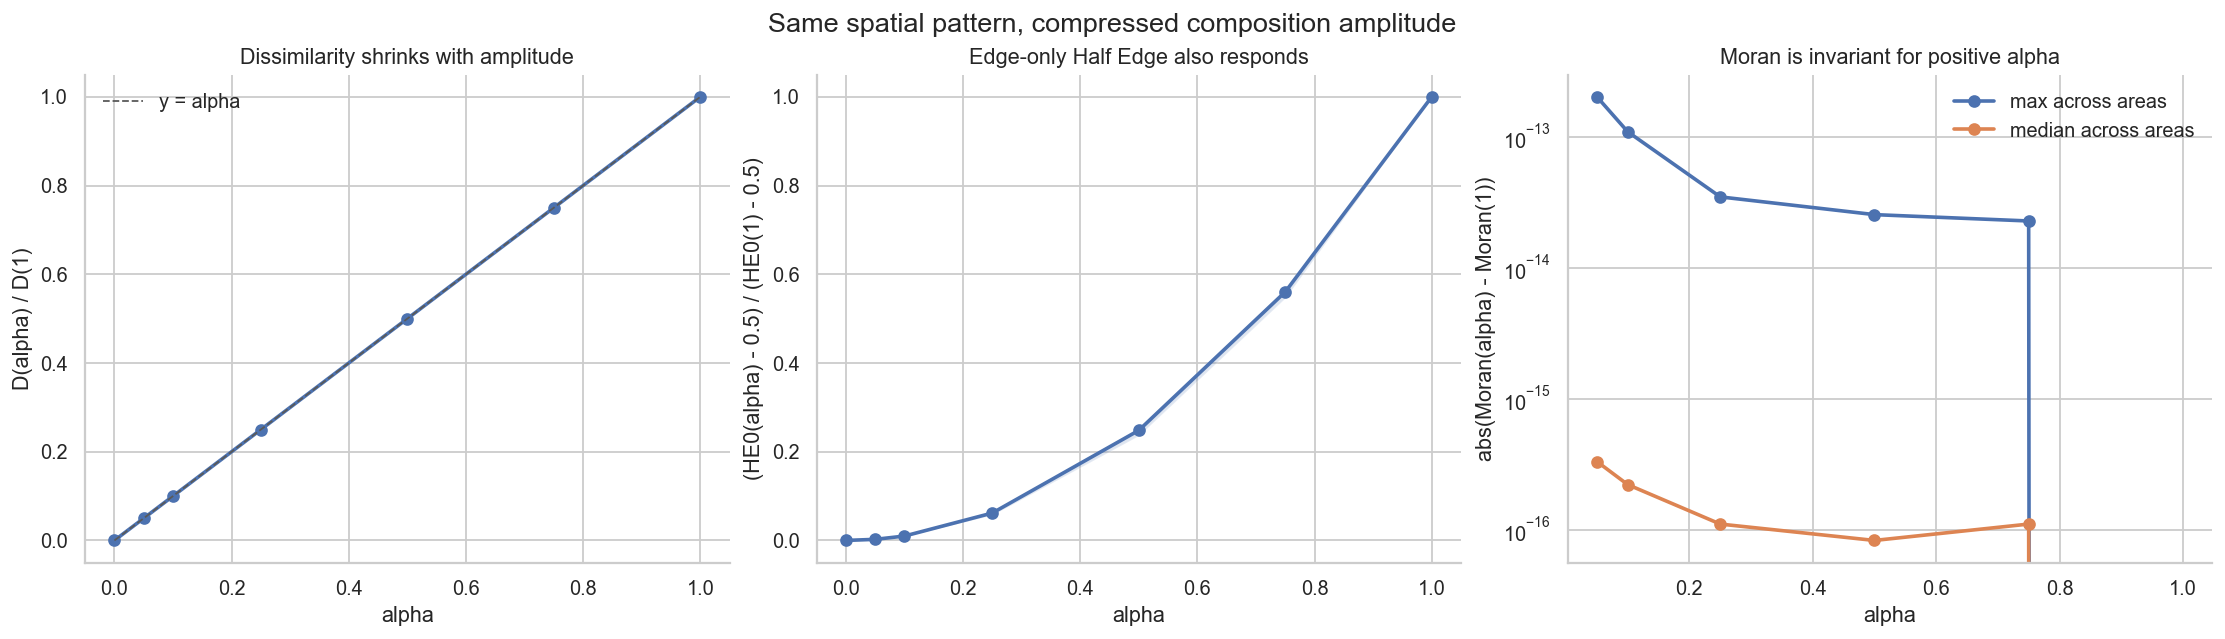

In [65]:
fig, axes = plt.subplots(ncols=3, figsize=(17, 4.8), constrained_layout=True)

axes[0].fill_between(
    alpha_summary["alpha"],
    alpha_summary["dissimilarity_ratio_p10"],
    alpha_summary["dissimilarity_ratio_p90"],
    alpha=0.18,
)
axes[0].plot(
    alpha_summary["alpha"],
    alpha_summary["dissimilarity_ratio_median"],
    marker="o",
    linewidth=2,
)
axes[0].plot([0, 1], [0, 1], color="0.35", linestyle="--", linewidth=1, label="y = alpha")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("D(alpha) / D(1)")
axes[0].set_title("Dissimilarity shrinks with amplitude")
axes[0].legend(frameon=False)

axes[1].fill_between(
    alpha_summary["alpha"],
    alpha_summary["he0_excess_ratio_p10"],
    alpha_summary["he0_excess_ratio_p90"],
    alpha=0.18,
)
axes[1].plot(
    alpha_summary["alpha"],
    alpha_summary["he0_excess_ratio_median"],
    marker="o",
    linewidth=2,
)
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("(HE0(alpha) - 0.5) / (HE0(1) - 0.5)")
axes[1].set_title("Edge-only Half Edge also responds")

positive_alpha_summary = alpha_summary[alpha_summary["alpha"].gt(0)]
axes[2].plot(
    positive_alpha_summary["alpha"],
    positive_alpha_summary["moran_abs_delta_max"],
    marker="o",
    linewidth=2,
    label="max across areas",
)
axes[2].plot(
    positive_alpha_summary["alpha"],
    positive_alpha_summary["moran_abs_delta_median"],
    marker="o",
    linewidth=2,
    label="median across areas",
)
axes[2].set_xlabel("alpha")
axes[2].set_ylabel("abs(Moran(alpha) - Moran(1))")
axes[2].set_yscale("log")
axes[2].set_title("Moran is invariant for positive alpha")
axes[2].legend(frameon=False)

fig.suptitle("Same spatial pattern, compressed composition amplitude", fontsize=15)
plt.show()

## Is The Edge-Only Half Edge Response Dissimilarity-Like?

At a fixed `alpha`, every graph has the same spatial pattern as observed. The question below is whether the amount by which edge-only Half Edge loses its excess above `0.5` tracks the amount by which dissimilarity falls.

It computes two “drops” from observed to compressed:
`dissimilarity_drop = D(1) - D(0.5)`,
`he0_excess_drop = [HE0(1) - 0.5] - [HE0(0.5) - 0.5]`


The - 0.5 part is there because edge-only Half Edge has a neutral/equal-share baseline of about 0.5. So we are asking how much of its “above neutral” value disappears when composition differences are weakened.

The plot then puts:

```
x-axis: how much dissimilarity falls
y-axis: how much edge-only Half Edge excess falls
Each dot is a CBSA-year graph.
```

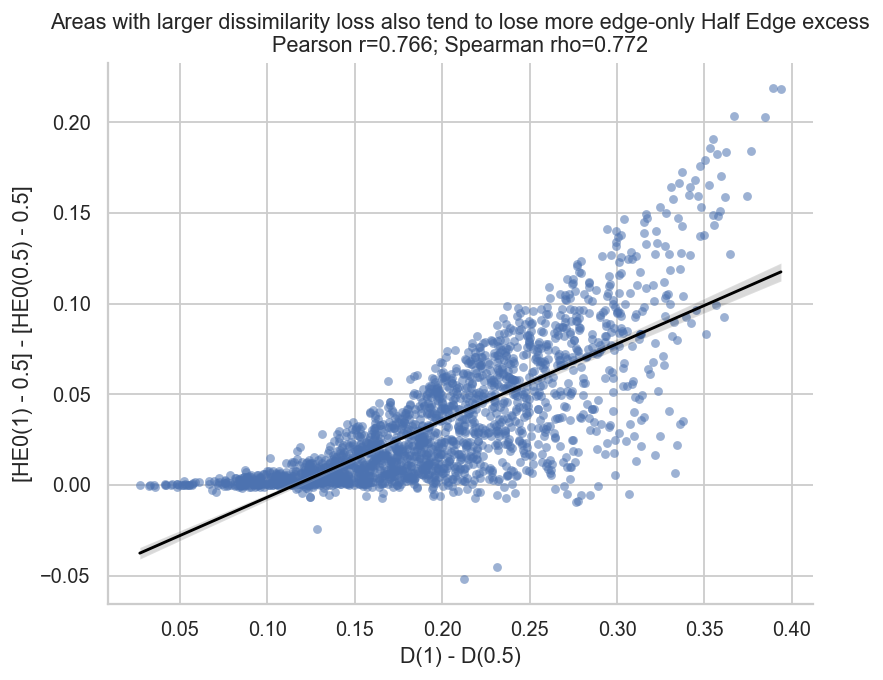

In [68]:
alpha_focus = 0.5
focus = counterfactual[counterfactual["alpha"].eq(alpha_focus)].copy()
focus["dissimilarity_drop"] = focus["observed_dissimilarity"] - focus["dissimilarity"]
focus["he0_excess_drop"] = focus["observed_he0_excess"] - focus["he0_excess"]

drop_corr = focus[["dissimilarity_drop", "he0_excess_drop"]].corr().iloc[0, 1]
drop_spearman = focus[["dissimilarity_drop", "he0_excess_drop"]].corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5.4))
sns.regplot(
    data=focus,
    x="dissimilarity_drop",
    y="he0_excess_drop",
    scatter_kws={"s": 24, "alpha": 0.55, "linewidths": 0},
    line_kws={"color": "black", "linewidth": 1.6},
    ax=ax,
)
ax.set_xlabel(f"D(1) - D({alpha_focus})")
ax.set_ylabel(f"[HE0(1) - 0.5] - [HE0({alpha_focus}) - 0.5]")
ax.set_title(
    "Areas with larger dissimilarity loss also tend to lose more edge-only Half Edge excess\n"
    f"Pearson r={drop_corr:.3f}; Spearman rho={drop_spearman:.3f}"
)
plt.show()

The edge-only part of Half Edge is sensitive to the same composition-amplitude signal that dissimilarity measures.

## Takeaway

This counterfactual isolates the between-only part of Half Edge. The graph and spatial ordering are unchanged; only the amplitude of tract composition differences is compressed.

If the results follow the expected pattern, Moran stays fixed because it normalizes by the variance of tract shares. Dissimilarity falls because the tract shares are closer to the CBSA mean. Edge-only Half Edge also moves because its edge products still carry the magnitude of compositional separation.

That means part of the Half Edge/Moran discrepancy is not a bug or only a within-term artifact. It is a substantive difference: edge-only Half Edge sees segregation intensity that Moran intentionally normalizes away.